# Plotting first few saccades

Required packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import ndimage, misc
import os
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

Load in your csv file, I've included a version of mine.

In [ ]:
data = pd.read_csv('SM01_full_table_Order.csv')
data.head(3)

,Unnamed: 0,subj,image,task,fixN,locs_1,locs_2,durs,SCamp,Order
0,1012,1,target_airport,memorize,3,559.0,634.0,265,11.57,1
1,1013,1,target_airport,memorize,4,533.0,209.0,216,3.44,1
2,1014,1,target_airport,memorize,5,448.0,108.0,238,1.91,1


Get a list of all images used in this task (you need to export your data from dataviewer with this as a column). Keep your images in a separate folder, and make sure that they are under the same image name in the folder.


In [ ]:
data.image.unique()

array(['target_airport', 'target_amusementpark'], dtype=object)

Set your image directory and an output directory for your plots.



In [ ]:
IM_DIRECTORY =  os.getcwd() + '/images/'
IM_FORMAT = '.png'
OUT_DIRECTORY = os.getcwd() + '/plots/'

Select how many saccades you want to plot, the size of the image presented, and what you want the duration cutoff to be.



In [ ]:
n_saccades = 5
min_dur = 50
max_dur = 1500
img_size = (768,1024)

# get only the fixations that meets the duration cutoffs
data = data.loc[(data['durs'] > min_dur) & (data['durs']< max_dur)]

# get only fixations that fall on image
data = data.loc[(data['locs_1'] < img_size[1]) & (data['locs_2'] < img_size[0])]

# drop the first fixation
data = data.loc[data['fixN'] != 1]
data.head(3)


,Unnamed: 0,subj,image,task,fixN,locs_1,locs_2,durs,SCamp,Order
0,1012,1,target_airport,memorize,3,559.0,634.0,265,11.57,1
1,1013,1,target_airport,memorize,4,533.0,209.0,216,3.44,1
2,1014,1,target_airport,memorize,5,448.0,108.0,238,1.91,1


Select how big you want the fixations to appear and pick the color you want for fixations. I used blue.




In [ ]:
cmap = ListedColormap(["blue"])
fix_size = 10

Function to make fixations a circle




In [ ]:
def circle_mask(img_size, center=None, radius=fix_size):
    if center is None: # use the middle of the image
        center = [int(img_size[1]/2), int(img_size[0]/2)]
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], img_size[1]-center[0], img_size[0]-center[1])

    Y, X = np.ogrid[:img_size[0], :img_size[1]]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

Loop through the images in the data frame and plot the first five fixations on the corresponding image. This works for me because my data is sorted by subj -> image -> fixN, but I would check to make sure that's how your data is sorted too!


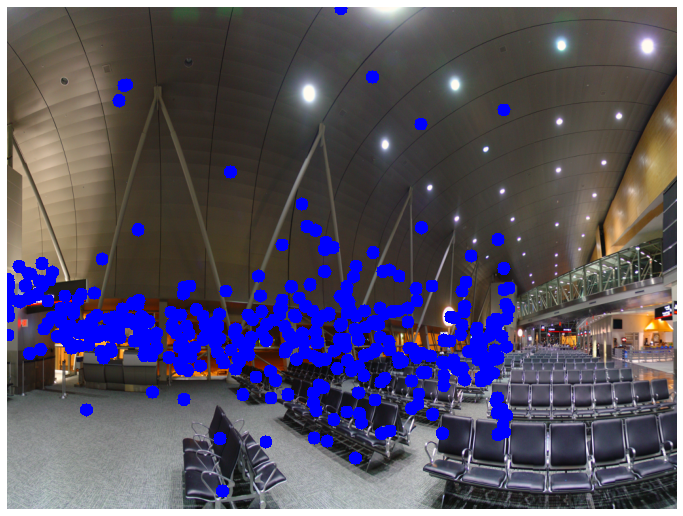

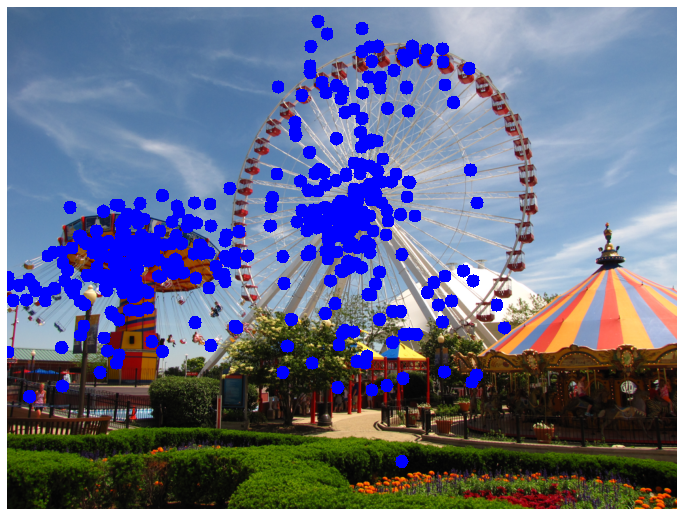

In [ ]:
for curr_im in data.image.unique():
  fixations = np.zeros((img_size[0], img_size[1]), dtype=np.float64)

  #loop through your subjects
  for curr_sub in data.subj.unique():
    curr_data = data.loc[(data['image'] == curr_im) & (data["subj"] == curr_sub)][:n_saccades-1]

  # plot fixations
    for idx, row in curr_data.iterrows():
      fixations = fixations + ((circle_mask(img_size, center=(row.locs_2, row.locs_1), radius=fix_size) * np.ones((img_size[0],img_size[1]),dtype=np.uint8)))

  # mask everything but the fixations in the fixation array
  masked_fixations = np.ma.masked_where(fixations <1, fixations)

  # load in image
  im =  plt.imread(IM_DIRECTORY + curr_im + IM_FORMAT)

  # now plot!
  fig, ax= plt.subplots(figsize=(12,12))
  ax.imshow(im, cmap=cm.gray)
  ax.imshow(masked_fixations, cmap=cmap, interpolation='none')
  plt.axis("off")
  plt.show()

  # save plots
  fig.savefig(OUT_DIRECTORY + curr_im + '.png', format='png')
